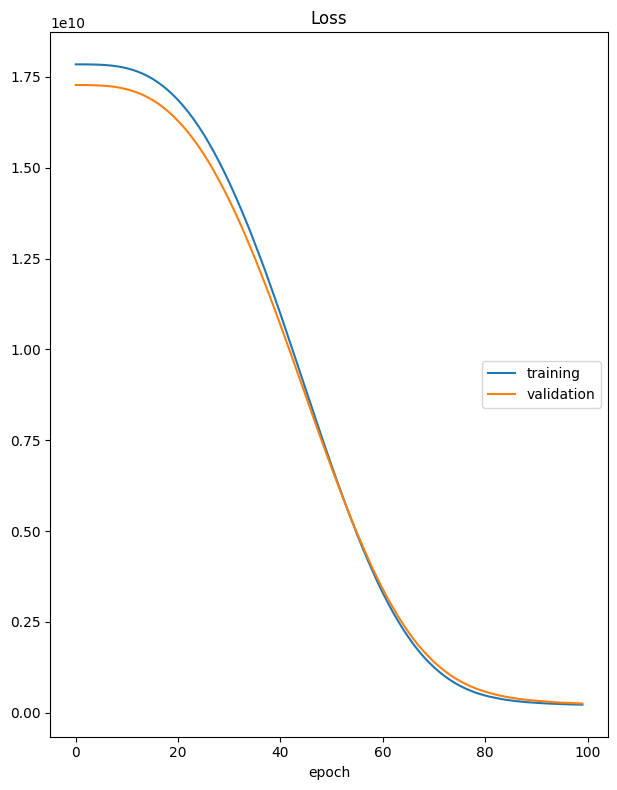

Loss
	training         	 (min: 222678976.000, max: 17842681856.000, cur: 222678976.000)
	validation       	 (min: 254920736.000, max: 17274646528.000, cur: 254920736.000)
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 222678976.0000 - val_loss: 254920736.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 254920704.0000
Model Loss: 254920704.0


In [1]:
#!pip install livelossplot
# housing_price_prediction_case_study.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from livelossplot import PlotLossesKerasTF

# Load the dataset
df = pd.read_csv("house.csv")

# Exploratory Data Analysis (EDA)
# Display the first few rows of the dataframe
print("First five rows of the dataset:")
print(df.head())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Visualize missing values
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Handling missing values
# For this example, we will fill numeric columns with the mean and categorical columns with the mode
for column in df.columns:
    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace=True)  # Fill categorical with mode
    else:
        df[column].fillna(df[column].mean(), inplace=True)  # Fill numeric with mean

# Verify that there are no missing values left
print("\nMissing values after treatment:")
print(df.isnull().sum())

# Data Visualization
# Price Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=10, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes([float,int]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Define features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Define a Column Transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['SqFt', 'Bedrooms', 'Bathrooms', 'Offers']),
        ('cat', OneHotEncoder(), ['Pool', 'Neighborhood'])
    ])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Building the Neural Network
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Training the Model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=5, verbose=1,
          callbacks=[PlotLossesKerasTF()])

# Evaluating the Model
loss = model.evaluate(X_test, y_test)
print(f"Model Loss: {loss}")
